In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
1
NVIDIA GeForce MX570 A


In [2]:
print("GPU:", torch.cuda.get_device_name(0))
print("Memory Allocated:", torch.cuda.memory_allocated(0))

GPU: NVIDIA GeForce MX570 A
Memory Allocated: 0


In [3]:
import os

In [4]:
%pwd

'd:\\Coding\\Data science\\Smart-Inventory-Defect-Detection-Quality-Control-API\\research'

In [5]:
os.chdir('../')

In [6]:
%pwd

'd:\\Coding\\Data science\\Smart-Inventory-Defect-Detection-Quality-Control-API'

In [18]:
import pandas as pd
import numpy as np
df = pd.read_csv("artifacts/data_ingestion/train.csv")

In [85]:
df.head(10)

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


In [20]:
rle = df["EncodedPixels"][0]

s = rle.split()

In [26]:
starts = np.asarray(s[0::2], dtype=int)
ends = np.asarray(s[1::2], dtype=int)

In [51]:
def rle_decode(mask_rle, shape):
    s = mask_rle.split()

    starts = np.asarray(s[0::2], dtype=int)
    lengths = np.asarray(s[1::2], dtype=int)

    starts -= 1
    ends = starts + lengths

    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)

    for start, end in zip(starts, ends):
        img[start:end] = 1

    return img.reshape(shape, order='F')

In [ ]:
mask = rle_decode(
    rle,
    (256,1600)
)

In [ ]:
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(256, 1600), dtype=uint8)

In [55]:
import matplotlib.pyplot as plt
from PIL import Image

In [58]:
grouped = df.groupby("ImageId")

In [86]:
grouped.get_group("002fc4e19.jpg")

,ImageId,ClassId,EncodedPixels
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


In [66]:
from pathlib import Path
import cv2

def load_image(image_id, train_images_dir):
    image_path = Path(train_images_dir) / image_id
    
    image = cv2.imread(str(image_path))
    
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    return image

In [61]:
def create_multi_mask(image_id, df, height, width, num_classes=4):
    
    mask = np.zeros((height, width, num_classes), dtype=np.uint8)

    group = df.groupby("ImageId").get_group(image_id)

    for _, row in group.iterrows():
        class_id = row["ClassId"]
        rle = row["EncodedPixels"]

        if pd.isna(rle):
            continue

        single_mask = rle_decode(rle, (height, width))

        mask[:, :, class_id - 1] = single_mask

    return mask

In [62]:
def visualize_multiclass_overlay(image, multi_mask):
    plt.figure(figsize=(10, 5))
    plt.imshow(image)

    colors = ["Reds", "Blues", "Greens", "Purples"]

    for i in range(multi_mask.shape[-1]):
        plt.imshow(multi_mask[:, :, i], cmap=colors[i], alpha=0.4)

    plt.axis("off")
    plt.show()

In [80]:
image_path_dir = Path("artifacts\data_ingestion\\train_images")

In [87]:
image = load_image("002fc4e19.jpg", image_path_dir) 

In [88]:
multi_mask = create_multi_mask("002fc4e19.jpg", df, 256, 1600, num_classes=4)

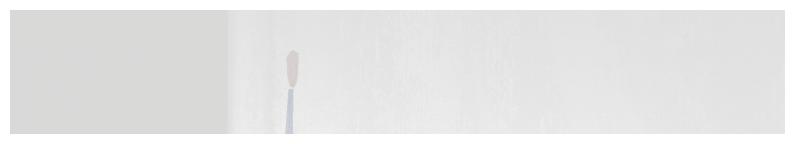

In [89]:
visualize_multiclass_overlay(image, multi_mask)

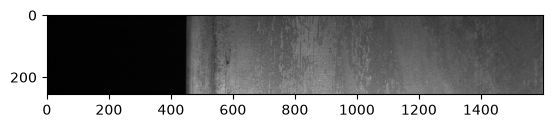

In [90]:
plt.imshow(image)